# Decisión binaria para observación 2-dupla


## Consigna

Considere un sistema de comunicaciones con dos hipótesis equiprobables.

Cuando $H=0$, se transmite

$$
c_0=[-1,-1].
$$

Cuando $H=1$, se transmite

$$
c_1=[1,1].
$$

El canal es AWGN:

$$
Y=c_i+Z,
$$

donde

$$
Z\sim \mathcal N(0,0.5I).
$$

Se pide:

1. Determinar la regla de decisión que el receptor debe implementar para minimizar la probabilidad de error.
2. Dibujar las regiones de decisión.
3. Calcular la probabilidad de error $P_e$ basándose en la regla de decisión anterior.


## Datos del problema

Las señales transmitidas son dos vectores en $\mathbb R^2$:

$$
c_0=\begin{bmatrix}-1\\-1\end{bmatrix},
\qquad
c_1=\begin{bmatrix}1\\1\end{bmatrix}.
$$

El ruido es gaussiano blanco en dos dimensiones:

$$
Z=\begin{bmatrix}Z_1\\Z_2\end{bmatrix},
\qquad
Z_1,Z_2\sim\mathcal N(0,0.5),
$$

con $Z_1$ y $Z_2$ independientes.

Entonces:

$$
Y\mid H=0\sim\mathcal N(c_0,0.5I),
\qquad
Y\mid H=1\sim\mathcal N(c_1,0.5I).
$$

Como las hipótesis son equiprobables, la regla MAP coincide con la regla ML. En AWGN con igual covarianza, eso equivale a elegir el punto de la constelación más cercano a la observación $y$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260508)

c0 = np.array([-1.0, -1.0])
c1 = np.array([1.0, 1.0])
sigma2 = 0.5
sigma = np.sqrt(sigma2)

def Q(x):
    return 0.5 * (1 - erf(x / sqrt(2)))


## 1. Regla de decisión óptima

La regla ML compara las densidades condicionales:

$$
f_{Y\mid H}(y\mid 1)
\overset{\hat H=1}{\underset{\hat H=0}{\gtreqless}}
f_{Y\mid H}(y\mid 0).
$$

Para un canal AWGN vectorial con covarianza $\sigma^2I$, las densidades son:

$$
f_{Y\mid H}(y\mid i)=\frac{1}{2\pi\sigma^2}
\exp\left[-\frac{\lVert y-c_i\rVert^2}{2\sigma^2}\right].
$$

Como el factor $1/(2\pi\sigma^2)$ es común, comparar densidades equivale a comparar distancias:

$$
\lVert y-c_1\rVert^2
\overset{\hat H=1}{\underset{\hat H=0}{\lesseqgtr}}
\lVert y-c_0\rVert^2.
$$

Es decir, se decide por la señal más cercana.


### Despeje de la frontera de decisión

Sea $y=[y_1,y_2]$. Entonces:

$$
\lVert y-c_1\rVert^2=(y_1-1)^2+(y_2-1)^2
$$

y

$$
\lVert y-c_0\rVert^2=(y_1+1)^2+(y_2+1)^2.
$$

La frontera se obtiene igualando ambas distancias:

$$
(y_1-1)^2+(y_2-1)^2=(y_1+1)^2+(y_2+1)^2.
$$

Expandimos ambos lados:

$$
y_1^2-2y_1+1+y_2^2-2y_2+1
=
y_1^2+2y_1+1+y_2^2+2y_2+1.
$$

Cancelamos términos comunes:

$$
-2y_1-2y_2=2y_1+2y_2.
$$

Pasando términos:

$$
4y_1+4y_2=0.
$$

Por lo tanto, la frontera es:

$$
\boxed{y_1+y_2=0}
$$

La regla de decisión queda:

$$
\boxed{\hat H=1 \quad \text{si} \quad y_1+y_2\ge 0}
$$

$$
\boxed{\hat H=0 \quad \text{si} \quad y_1+y_2<0}
$$


## 2. Regiones de decisión

La recta $y_1+y_2=0$ separa las dos regiones:

$$
R_1=\{y:y_1+y_2\ge0\}
$$

$$
R_0=\{y:y_1+y_2<0\}
$$

Geométricamente, la frontera es la mediatriz entre $c_0$ y $c_1$.


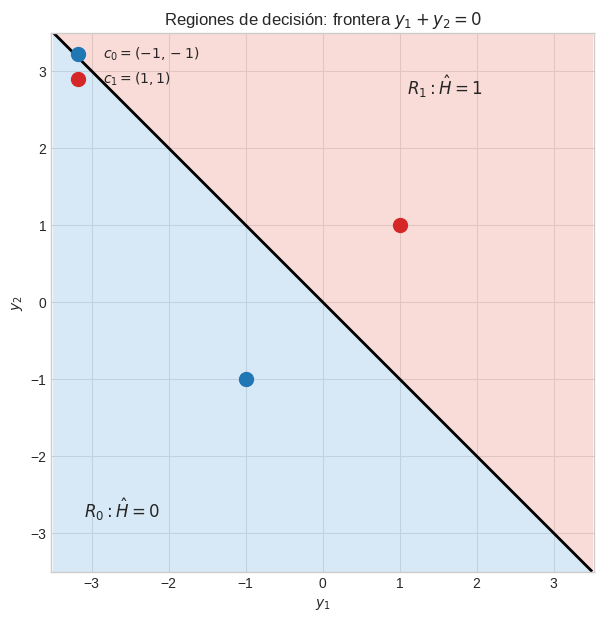

In [2]:
grid = np.linspace(-3.5, 3.5, 400)
Y1, Y2 = np.meshgrid(grid, grid)
decision_region = (Y1 + Y2 >= 0).astype(int)

plt.figure(figsize=(7, 7))
plt.contourf(Y1, Y2, decision_region, levels=[-0.5, 0.5, 1.5], colors=["#B7D7F0", "#F5C0B8"], alpha=0.55)
plt.contour(Y1, Y2, Y1 + Y2, levels=[0], colors="black", linewidths=2)
plt.scatter(c0[0], c0[1], color="tab:blue", s=100, label=r"$c_0=(-1,-1)$")
plt.scatter(c1[0], c1[1], color="tab:red", s=100, label=r"$c_1=(1,1)$")
plt.text(-3.1, -2.8, r"$R_0: \hat H=0$", fontsize=12)
plt.text(1.1, 2.7, r"$R_1: \hat H=1$", fontsize=12)
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
plt.title(r"Regiones de decisión: frontera $y_1+y_2=0$")
plt.axis("equal")
plt.legend()
plt.show()


## 3. Probabilidad de error $P_e$

La regla depende de la suma

$$
T=Y_1+Y_2.
$$

Esta suma es una estadística suficiente para esta decisión binaria, porque la frontera solo depende de $y_1+y_2$.

Bajo $H=0$:

$$
Y=c_0+Z=[-1,-1]+[Z_1,Z_2]
$$

entonces:

$$
T=Y_1+Y_2=-2+Z_1+Z_2.
$$

Como $Z_1$ y $Z_2$ son independientes y cada uno tiene varianza $0.5$:

$$
Z_1+Z_2\sim\mathcal N(0,1).
$$

Por lo tanto:

$$
T\mid H=0\sim\mathcal N(-2,1).
$$

Hay error bajo $H=0$ si se decide $H=1$, o sea si $T\ge0$:

$$
P(e\mid H=0)=P(T\ge0\mid H=0)=Q\left(\frac{0-(-2)}{1}\right)=Q(2).
$$

Bajo $H=1$:

$$
T=Y_1+Y_2=2+Z_1+Z_2,
$$

por lo tanto:

$$
T\mid H=1\sim\mathcal N(2,1).
$$

Hay error bajo $H=1$ si se decide $H=0$, o sea si $T<0$:

$$
P(e\mid H=1)=P(T<0\mid H=1)=Q(2).
$$

Como las hipótesis son equiprobables:

$$
P_e=\frac{1}{2}P(e\mid H=0)+\frac{1}{2}P(e\mid H=1).
$$

Entonces:

$$
\boxed{P_e=Q(2)}
$$


In [3]:
pe_exact = Q(2)
print(f"Pe = Q(2) = {pe_exact:.8f}")


Pe = Q(2) = 0.02275013


## Verificación por Monte Carlo

Se simula la transmisión de muchas hipótesis equiprobables, se agrega ruido AWGN y se aplica la regla $y_1+y_2\ge0$.


In [4]:
n_samples = 500000
h = rng.integers(0, 2, size=n_samples)
sent = np.where(h[:, None] == 0, c0, c1)
noise = rng.normal(loc=0.0, scale=sigma, size=(n_samples, 2))
y = sent + noise
h_hat = (y[:, 0] + y[:, 1] >= 0).astype(int)
pe_mc = np.mean(h_hat != h)

print(f"Pe exacta:      {pe_exact:.8f}")
print(f"Pe Monte Carlo: {pe_mc:.8f}")
print(f"Error absoluto: {abs(pe_exact - pe_mc):.8f}")


Pe exacta:      0.02275013
Pe Monte Carlo: 0.02280200
Error absoluto: 0.00005187


## Respuesta final

La regla óptima es:

$$
\boxed{\hat H=1 \quad \text{si} \quad y_1+y_2\ge0}
$$

$$
\boxed{\hat H=0 \quad \text{si} \quad y_1+y_2<0}
$$

La frontera de decisión es:

$$
\boxed{y_1+y_2=0}
$$

La probabilidad de error es:

$$
\boxed{P_e=Q(2)\approx0.02275}
$$
